# [LDSSA Hackathon 4] – Predicting Judicial Recommendations for Clemency (NLP Specialisation)

This notebook aims to build and evaluate NLP models for predicting judicial recommendations for clemency from historical judges’ reports at the Old Bailey (1784–1827).

* Author: Jessica Rodrigues  
* Dataset preparation: Laszlo Taba  
* Date: 31-01-2026

In [846]:
import numpy as np
import pandas as pd
from pathlib import Path
pd.set_option('display.max_colwidth', None)

In [847]:
# project directory
project_dir = Path(".").resolve().parent

## 1. Task definition

The task is to predict the judicial recommendation for clemency associated with a historical criminal case. The problem is formulated as a supervised multi-class classification task, where each case is assigned one of three labels: **FAVOURABLE**, **UNFAVOURABLE**, or **NO_CLEAR_RECOMMENDATION**.

Classification is performed at the level of individual cases, without assuming links between multiple records referring to the same individual.

## 2. Data

The dataset used in this notebook is [*Judges’ Reports on Criminals convicted at the Old Bailey, 1784–1827*](https://orda.shef.ac.uk/articles/dataset/Judges_Reports_on_Criminals_convicted_at_the_Old_Bailey_1784-1827/5712118). It consists of structured summaries derived from judges’ reports and related documents concerning individuals convicted at the Old Bailey between 1784 and 1827.

The dataset was created as part of the Digital Panopticon project and is based on item-level descriptions from the Home Office series HO 47 held at The National Archives (UK). The descriptions are archival summaries rather than full transcripts of the original documents.

Each row represents an individual case. An individual may appear more than once, and no attempt is made to link multiple records referring to the same person.

For the purposes of the hackathon, the original dataset has been simplified to retain only a small number of descriptive textual fields and the target label, in order to focus the task on textual reasoning and avoid information leakage.

### Dataset columns

- `crime`: Description of the offence.  
- `initial_sentence`: Sentence passed at trial, as described.  
- `grounds_clemency`: Stated grounds cited in favour of clemency.  
- `additional_info`: Additional contextual information.  
- `doc_description`: Archivist description of the document.  
- `label`: Target variable used in this notebook.

### 2.1 Train and test sets

The dataset is split into training and test sets, stratified by the target label.

In [848]:
TRAIN_FILE = project_dir / "data" / "trials_train.csv"
TEST_FILE = project_dir / "data" / "trials_test.csv"

In [849]:
df_train = pd.read_csv(TRAIN_FILE, delimiter=",", header=0, encoding='utf-8', engine='python')
df_test = pd.read_csv(TEST_FILE, delimiter=",", header=0, encoding='utf-8', engine='python')

In [850]:
DROP_COLS = ["Unnamed: 0", "recommendation_type"]

df_train = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns])
df_test = df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns])

#df_test = df_test.drop(columns=["label"])

In [851]:
print("Train set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

print("\nTrain columns:")
print(df_train.columns.tolist())

print("\nTest columns:")
print(df_test.columns.tolist())

Train set shape: (901, 4)
Test set shape: (226, 4)

Train columns:
['grounds_clemency', 'additional_info', 'doc_description', 'label']

Test columns:
['grounds_clemency', 'additional_info', 'doc_description', 'label']


In [852]:
print("Unique labels in train:")
print(df_train["label"].value_counts())

print("\nLabel column present in test:")
print("label" in df_test.columns)

Unique labels in train:
label
FAVOURABLE                 430
UNFAVOURABLE               280
NO_CLEAR_RECOMMENDATION    191
Name: count, dtype: int64

Label column present in test:
True


### 2.2 Dataset overview

The dataset contains 1,127 records, each corresponding to an individual criminal case. It includes a mixture of textual fields, categorical variables, and sparse demographic information. Key text fields vary in length and completeness, reflecting the archival nature of the source material.

The dataset contains missing values in several fields, particularly in demographic and contextual columns.

In [853]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   grounds_clemency  629 non-null    object
 1   additional_info   802 non-null    object
 2   doc_description   901 non-null    object
 3   label             901 non-null    object
dtypes: object(4)
memory usage: 28.3+ KB


In [854]:
pd.DataFrame({
    "missing_values": df_train.isna().sum(),
    "missing_percentage": (df_train.isna().mean() * 100).round(2)
})

,missing_values,missing_percentage
grounds_clemency,272,30.19
additional_info,99,10.99
doc_description,0,0.00
label,0,0.00


In [855]:
for col in ["grounds_clemency", "additional_info", "doc_description"]:
    non_empty = df_train[col].fillna("").str.strip().ne("").mean() * 100
    print(f"{col}: {non_empty:.2f}% non-empty")

grounds_clemency: 69.81% non-empty
additional_info: 89.01% non-empty
doc_description: 100.00% non-empty


### 2.3 Label distribution

The target variable `label` is imbalanced across the three classes. Most cases are labelled **FAVOURABLE**, followed by **NO_CLEAR_RECOMMENDATION**, with **UNFAVOURABLE** representing the smallest class.

This imbalance is taken into account during model training and evaluation.

In [856]:
label_counts = df_train["label"].value_counts()
label_percentages = df_train["label"].value_counts(normalize=True) * 100

pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages.round(2)
})

,count,percentage
label,,
FAVOURABLE,430,47.72
UNFAVOURABLE,280,31.08
NO_CLEAR_RECOMMENDATION,191,21.20


<AxesSubplot:title={'center':'Label distribution'}, xlabel='label'>

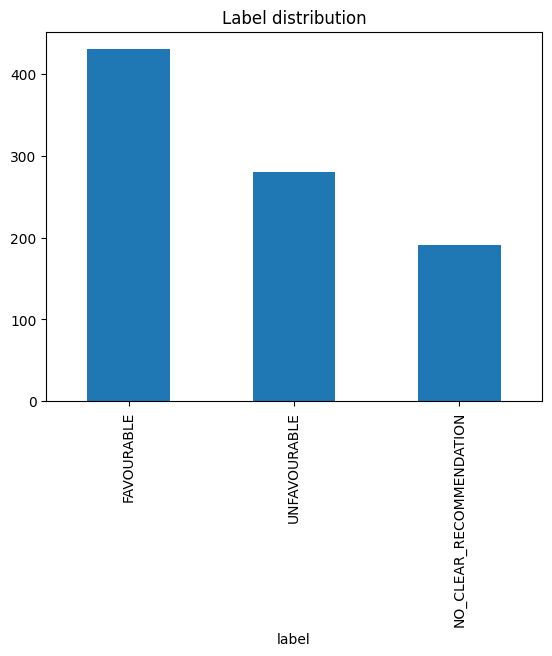

In [857]:
label_counts.plot(kind="bar", title="Label distribution")

### 2.4 Text statistics

The main textual fields in the dataset vary in length and completeness. Most entries contain short to medium-length text, with a small number of empty or very brief records. Text length statistics are reported to provide basic insight into the scale and variability of the textual input.

In [858]:
text_cols = ["grounds_clemency", "additional_info", "doc_description"]

for col in text_cols:
    lengths = df_train[col].fillna("").str.len()
    print(f"\n{col}")
    print(lengths.describe())


grounds_clemency
count    901.000000
mean     131.632630
std      149.590409
min        0.000000
25%        0.000000
50%       92.000000
75%      212.000000
max      948.000000
Name: grounds_clemency, dtype: float64

additional_info
count     901.000000
mean      234.699223
std       262.288208
min         0.000000
25%        69.000000
50%       152.000000
75%       297.000000
max      2160.000000
Name: additional_info, dtype: float64

doc_description
count    901.000000
mean     197.339623
std       97.972899
min       51.000000
25%      103.000000
50%      194.000000
75%      268.000000
max      651.000000
Name: doc_description, dtype: float64


<AxesSubplot:>

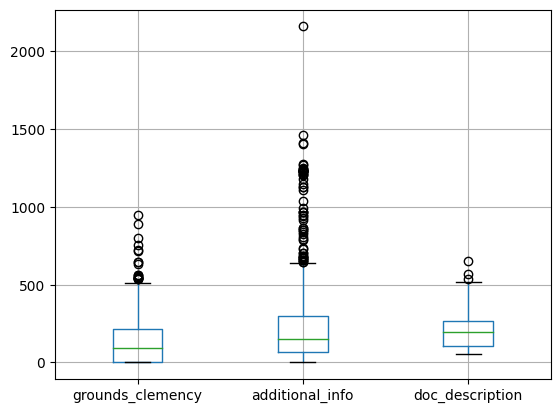

In [859]:
lengths_df = pd.DataFrame({
    col: df_train[col].fillna("").str.len()
    for col in text_cols
})

lengths_df.boxplot()

## 3. Evaluation

Model performance is evaluated using standard classification metrics. Given the class imbalance in the target variable, evaluation focuses on metrics that account for per-class performance rather than overall accuracy.

In [860]:
from sklearn.metrics import classification_report, f1_score

### 3.1 Metrics

Model performance is evaluated using the macro-averaged F1 score as the primary metric. Additional metrics, including per-class precision and recall, are reported for diagnostic purposes.

In [861]:
y_true = df_train["label"]
y_pred = [majority_label] * len(y_true)

macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro-F1 (majority baseline): {macro_f1:.4f}")

Macro-F1 (majority baseline): 0.2154


## 4. Modelling

This section describes the models used to address the classification task. A baseline model is first established, followed by progressively improved approaches.

In [862]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer

In [863]:
y_train = df_train["label"].values
y_test = df_test["label"].values

### 4.1 Baseline

A baseline classification model is used to establish a reference level of performance. The baseline uses only the `grounds_clemency` field as input, as it is the most directly related to the reasoning presented in support of clemency. The text is represented using TF–IDF features and classified with a logistic regression model with class-balanced weights.

In [864]:
BASELINE_TEXT_COL = "grounds_clemency"

In [865]:
baseline_single = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=10000
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

In [867]:
baseline_single.fit(df_train[BASELINE_TEXT_COL].fillna("").astype(str), y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    n_jobs=-1, random_state=42))])

In [868]:
y_pred_base = baseline_single.predict(df_test[BASELINE_TEXT_COL].fillna("").astype(str))

In [869]:
print(classification_report(y_test, y_pred_base, digits=3))

baseline_single_macro_f1 = f1_score(y_test, y_pred_base, average="macro")
print(f"Baseline (single field) macro-F1: {baseline_single_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.605     0.743     0.667       101
NO_CLEAR_RECOMMENDATION      0.240     0.146     0.182        41
           UNFAVOURABLE      0.610     0.560     0.584        84

               accuracy                          0.566       226
              macro avg      0.485     0.483     0.477       226
           weighted avg      0.541     0.566     0.548       226

Baseline (single field) macro-F1: 0.4774


### Baseline results

Using only the `grounds_clemency` field as input yields limited performance, with a macro-averaged F1 score of 0.477.

Performance is particularly low for **NO_CLEAR_RECOMMENDATION** (F1: 0.182), indicating that this class cannot be reliably inferred from the stated grounds alone. Predictions for **FAVOURABLE** and **UNFAVOURABLE** cases are moderately better but remain substantially below later models.

This baseline establishes a minimal reference point and highlights the importance of incorporating broader contextual information beyond the grounds for clemency.

### 4.2 Instructors’ solution

The instructors’ solution extends the baseline by incorporating additional textual context beyond the stated grounds for clemency. Text from multiple fields is combined and represented using TF–IDF features, and a logistic regression classifier with class-balanced weights is used for prediction.

In [870]:
TEXT_COLUMNS = ["grounds_clemency", "additional_info", "doc_description"]

def merge_text_fields(df, text_cols):
    return (
        df[text_cols]
        .fillna("")
        .apply(lambda row: " ".join(t for t in row if t), axis=1)
        .str.strip()
    )

df_train["text"] = merge_text_fields(df_train, TEXT_COLUMNS)
df_test["text"] = merge_text_fields(df_test, TEXT_COLUMNS)
print(df_train["text"].str.len().describe())

count     901.000000
mean      565.254162
std       353.877246
min        64.000000
25%       284.000000
50%       500.000000
75%       738.000000
max      2703.000000
Name: text, dtype: float64


In [871]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=10000
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

### 4.2 Training

Models are trained on the training split using the selected input features and labels. Hyperparameters are fixed, and training is performed with class-balanced weighting to account for label imbalance.

In [872]:
baseline.fit(df_train["text"], y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    n_jobs=-1, random_state=42))])

### 4.3 Prediction

Trained models are used to generate predictions on the held-out test set. Predicted labels are compared against the ground truth for evaluation.

In [873]:
y_pred = baseline.predict(df_test["text"])

### 4.4 Evaluation

Model performance is evaluated on the test set using the metrics defined in Section 3. Results are reported at both the overall and per-class levels.

In [874]:
print(classification_report(y_test, y_pred, digits=3))

baseline_macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Baseline macro-F1: {baseline_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.918     0.772     0.839       101
NO_CLEAR_RECOMMENDATION      0.765     0.634     0.693        41
           UNFAVOURABLE      0.710     0.905     0.796        84

               accuracy                          0.796       226
              macro avg      0.798     0.770     0.776       226
           weighted avg      0.813     0.796     0.796       226

Baseline macro-F1: 0.7760


### Instructors’ solution results

- **Overall performance**
  - Macro-averaged F1: 0.776 (baseline: 0.477)
- **Class-level comparison with the baseline**
  - **FAVOURABLE**: precision increases from 0.605 to 0.918
  - **UNFAVOURABLE**: recall increases from 0.560 to 0.905
  - **NO_CLEAR_RECOMMENDATION**: performance improves substantially but remains the lowest (F1: 0.693)
- **Effect of additional textual inputs**
  - Incorporating multiple textual fields introduces procedural and contextual information absent from the grounds alone.
  - These fields provide implicit signals of judicial stance that improve discrimination between favourable and unfavourable cases.
- **Remaining limitations**
  - Performance for **NO_CLEAR_RECOMMENDATION** remains constrained by the absence of explicit evaluative language.

Overall, the instructors’ solution demonstrates that broader textual context is critical for accurately modelling judicial recommendations in this dataset.

## 5. Analysis

This section examines model behaviour beyond aggregate performance metrics. Emphasis is placed on understanding systematic errors and class-specific patterns.

In [875]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### 5.1 Error analysis

Misclassified cases are examined to identify common sources of error. Particular attention is paid to confusions between adjacent or ambiguous classes.

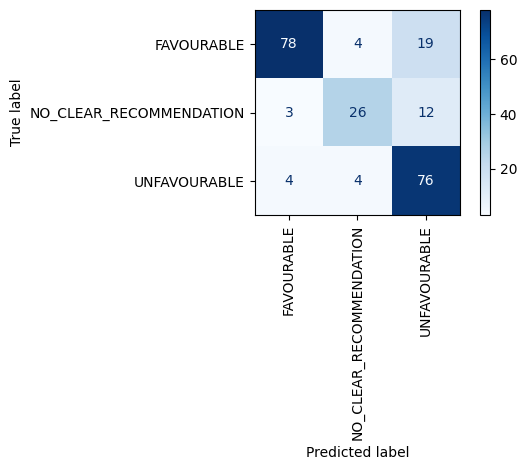

In [876]:
cm = confusion_matrix(y_test, y_pred, labels=baseline.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=baseline.classes_
)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.tight_layout()
plt.show()

In [877]:
vectorizer = baseline.named_steps["tfidf"]
classifier = baseline.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = classifier.coef_
classes = classifier.classes_

In [878]:
def top_features_for_class(class_idx, top_k=20):
    coef = coefs[class_idx]
    top_idx = np.argsort(coef)[-top_k:][::-1]
    return pd.DataFrame({
        "ngram": feature_names[top_idx],
        "weight": coef[top_idx]
    })

for i, cls in enumerate(classes):
    print(f"\nTop features for class: {cls}")
    display(top_features_for_class(i, top_k=20))


Top features for class: FAVOURABLE


,ngram,weight
0,serve,0.843565
1,to serve,0.819732
2,on prisoners,0.666592
3,serve as,0.647785
4,recommended,0.641060
5,free,0.639454
6,free pardon,0.638560
7,prisoners convicted,0.621754
8,recommended to,0.620868
9,West Indies,0.590318



Top features for class: NO_CLEAR_RECOMMENDATION


,ngram,weight
0,Petition,1.004067
1,Petition on,0.908382
2,from John,0.782964
3,to be,0.705767
4,respited prisoners,0.693965
5,on respited,0.693965
6,good behaviour,0.688659
7,transported,0.660351
8,be,0.656100
9,transported for,0.636452



Top features for class: UNFAVOURABLE


,ngram,weight
0,no mercy,1.281482
1,none given,1.218096
2,none,1.184675
3,mercy Report,1.160581
4,transportation no,1.115568
5,no,0.970876
6,mercy,0.892968
7,servant,0.777210
8,petition on,0.748139
9,The,0.745344


In [879]:
def ngram_length_distribution(class_idx, top_k=50):
    coef = coefs[class_idx]
    top_idx = np.argsort(coef)[-top_k:]
    ngrams = feature_names[top_idx]
    lengths = [len(ng.split()) for ng in ngrams]
    return pd.Series(lengths).value_counts().sort_index()

for i, cls in enumerate(classes):
    print(f"\nN-gram length distribution for class: {cls}")
    print(ngram_length_distribution(i, top_k=50))


N-gram length distribution for class: FAVOURABLE
1    23
2    27
Name: count, dtype: int64

N-gram length distribution for class: NO_CLEAR_RECOMMENDATION
1    26
2    24
Name: count, dtype: int64

N-gram length distribution for class: UNFAVOURABLE
1    29
2    21
Name: count, dtype: int64


In [880]:
def bigram_ratio(class_idx, top_k=50):
    coef = coefs[class_idx]
    top_idx = np.argsort(coef)[-top_k:]
    ngrams = feature_names[top_idx]
    return sum(len(ng.split()) == 2 for ng in ngrams) / top_k

for i, cls in enumerate(classes):
    ratio = bigram_ratio(i, top_k=50)
    print(f"{cls}: {ratio:.2%} bi-grams among top features")

FAVOURABLE: 54.00% bi-grams among top features
NO_CLEAR_RECOMMENDATION: 48.00% bi-grams among top features
UNFAVOURABLE: 42.00% bi-grams among top features


### Error analysis

Inspection of the most influential n-grams reveals distinct lexical patterns across classes.

- **FAVOURABLE**  
  High-weight features are dominated by terms related to mitigation and alternative punishments, including *serve*, *to serve*, *free*, *free pardon*, *recommended*, and references to *transportation* and overseas destinations such as *West Indies*. Among the top features, 54% are bi-grams, indicating that favourable recommendations are often expressed through multi-word constructions.

- **NO_CLEAR_RECOMMENDATION**  
  The most influential features are procedural and administrative in nature, with high weights assigned to terms such as *petition*, *letter*, *received*, *security*, and *respited*. These features reflect document handling and correspondence rather than evaluative judgement. Bi-grams account for 48% of the top features, suggesting a mixed reliance on single-word and multi-word expressions.

- **UNFAVOURABLE**  
  Predictions are strongly driven by explicit negations of mercy, with *no mercy*, *none given*, *none*, and *mercy report* among the highest-weight features. This class shows the highest concentration of unigrams, with bi-grams comprising 42% of the top features, consistent with direct and formulaic expressions of refusal.

Overall, the feature analysis indicates that the baseline model relies on surface lexical cues. Classes associated with explicit evaluative language are more easily distinguished, while procedural or descriptive language contributes to ambiguity between unfavourable and unclear recommendations.

In [881]:
X_test_tfidf = vectorizer.transform(df_test["text"])

def explain_instance(idx, top_k=10):
    x = X_test_tfidf[idx]
    true_label = y_true[idx]
    pred_label = y_pred[idx]

    pred_class_idx = np.where(classes == pred_label)[0][0]
    coef = coefs[pred_class_idx]

    contrib = x.multiply(coef).toarray().ravel()
    nz = x.nonzero()[1]
    contrib_nz = contrib[nz]

    top_pos_idx = nz[np.argsort(contrib_nz)[-top_k:][::-1]]
    top_neg_idx = nz[np.argsort(contrib_nz)[:top_k]]

    return {
        "true": true_label,
        "pred": pred_label,
        "supporting_ngrams": pd.DataFrame({
            "ngram": feature_names[top_pos_idx],
            "contribution": contrib[top_pos_idx]
        }),
        "opposing_ngrams": pd.DataFrame({
            "ngram": feature_names[top_neg_idx],
            "contribution": contrib[top_neg_idx]
        })
    }

In [882]:
mis_sample = mis_idx[:5]

for idx in mis_sample:
    exp = explain_instance(idx, top_k=8)
    print(f"\nIndex: {idx} | True: {exp['true']} | Pred: {exp['pred']}")
    print("Text snippet:")
    print(df_test.iloc[idx]["text"][:400].replace("\n", " ") + "...")
    print("\nTop n-grams supporting the prediction:")
    display(exp["supporting_ngrams"])
    print("Top n-grams opposing the prediction:")
    display(exp["opposing_ngrams"])


Index: 0 | True: NO_CLEAR_RECOMMENDATION | Pred: UNFAVOURABLE
Text snippet:
A report cannot be sent at present as the presiding judge, Mr Justice Ashurst, is absent. This being the case a transcript from the short-hand notes taken at the trial is enclosed. The transcript concerns Richard Manley, journeyman bookbinder, indicted on 23 May, for stealing 7 printed bound books, value 20/-, property of Thomas Cadell, bookshop keeper, on 23 May 1789 (same day). Evidences supplie...

Top n-grams supporting the prediction:


,ngram,contribution
0,The,0.086245
1,journeyman,0.046065
2,servant,0.044152
3,keeper,0.037946
4,value,0.037708
5,of Thomas,0.037581
6,servant to,0.032046
7,Thomas,0.029926


Top n-grams opposing the prediction:


,ngram,contribution
0,Letter,-0.041449
1,sent,-0.027201
2,report,-0.022382
3,and the,-0.020967
4,be,-0.020350
5,23,-0.019658
6,with the,-0.017491
7,on 23,-0.016513



Index: 10 | True: NO_CLEAR_RECOMMENDATION | Pred: NO_CLEAR_RECOMMENDATION
Text snippet:
youth (23 years), of previous good character, 'a natural child'/illegitimate but from a respectable family (in Paris), educated, offered a position by 1 of the petitioners, imprisonment will lead to illness, witnesses were unable to attend the court, has an offer of future employment if released, had pawned her clothes to provide for herself, stole the watch so that she could appear in respectable...

Top n-grams supporting the prediction:


...

,ngram,contribution
0,prison,-0.031419
1,in prison,-0.028498
2,commit,-0.020294
3,crime,-0.017766
4,prosecutor and,-0.016597
5,to commit,-0.016235
6,before,-0.015658
7,names,-0.014370



Index: 16 | True: FAVOURABLE | Pred: UNFAVOURABLE
Text snippet:
she is very young and inexperienced and had lived with Thomas Parker as his wife, thus was greatly influenced by him and very attached to him until his execution and she has herself 'tasted the Bitterness of Death in Respect of Several Reprieves'.  Report of John Heath on Sophia Gurton, convicted (with Thomas Parker) at the 'last' sessions at the Old Bailey, 'for counterfeiting his majesty's silve...

Top n-grams supporting the prediction:


,ngram,contribution
0,she,0.076299
1,with Thomas,0.046839
2,young,0.039483
3,wife,0.037326
4,Thomas,0.032659
5,Parker,0.028942
6,Thomas Parker,0.026264
7,Sophia,0.025513


Top n-grams opposing the prediction:


,ngram,contribution
0,until,-0.031955
1,to him,-0.028094
2,and she,-0.019600
3,very,-0.019199
4,him and,-0.016738
5,attached to,-0.014273
6,attached,-0.014273
7,is very,-0.013578


### Case-level error analysis

Analysis of individual predictions highlights several recurring patterns.

- **Procedural and factual descriptions**  
  Cases labelled **NO_CLEAR_RECOMMENDATION** but predicted as **UNFAVOURABLE** often contain procedural or factual language (e.g. references to reports, petitions, trials, or occupations) without an explicit evaluative statement. In the absence of clear stance markers, the model defaults to an unfavourable interpretation.

- **Narrative detail without judgement**  
  Correct **NO_CLEAR_RECOMMENDATION** predictions are typically driven by detailed accounts of personal circumstances or case context that do not culminate in a judicial recommendation.

- **Implicit mitigation signals**  
  Some **FAVOURABLE** cases are misclassified when mitigating factors such as youth, dependency, or personal influence are described implicitly or embedded in complex narratives rather than expressed through explicit recommendations.

- **Reliance on surface cues**  
  The baseline model relies primarily on surface lexical cues. When explicit markers of mercy or refusal are absent, predictions become sensitive to contextual or administrative language rather than judicial intent.

## 6. Alternative Solution

This section explores alternative modelling approaches aimed at improving performance over the baseline. Improvements focus on feature representation and model architecture.

In [883]:
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

### 6.1 Latent Semantic Analysis (TF–IDF + TruncatedSVD)

In [884]:
lsa = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=10000
    )),
    ("svd", TruncatedSVD(n_components=300, random_state=42)),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

#### 6.1.1 Training

In [885]:
lsa.fit(df_train["text"], y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('svd', TruncatedSVD(n_components=300, random_state=42)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    n_jobs=-1, random_state=42))])

#### 6.1.2 Prediction

In [886]:
y_pred_lsa = lsa.predict(df_test["text"])

#### 6.1.3 Evaluation

In [887]:
print(classification_report(y_test, y_pred_lsa, digits=3))

lsa_macro_f1 = f1_score(y_test, y_pred_lsa, average="macro")
print(f"LSA macro-F1: {lsa_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.928     0.762     0.837       101
NO_CLEAR_RECOMMENDATION      0.758     0.610     0.676        41
           UNFAVOURABLE      0.709     0.929     0.804        84

               accuracy                          0.796       226
              macro avg      0.798     0.767     0.772       226
           weighted avg      0.816     0.796     0.795       226

LSA macro-F1: 0.7723


### LSA results

The LSA model achieves similar overall performance to the baseline, with a macro-averaged F1 score of 0.772. Performance remains strongest for **FAVOURABLE** (F1: 0.837) and **UNFAVOURABLE** (F1: 0.804). The lowest performance is again observed for **NO_CLEAR_RECOMMENDATION** (F1: 0.676).

Overall, applying TruncatedSVD does not improve macro-F1 under the current settings and test split.

### 6.2 Sentence embeddings + Logistic Regression

In [888]:
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

/opt/homebrew/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [889]:
X_train_text = df_train["text"].fillna("").astype(str).tolist()
X_test_text = df_test["text"].fillna("").astype(str).tolist()

X_train_emb = embedder.encode(
    X_train_text, 
    batch_size=64, 
    show_progress_bar=True, 
    normalize_embeddings=True
)

X_test_emb = embedder.encode(
    X_test_text, 
    batch_size=64, 
    show_progress_bar=True, 
    normalize_embeddings=True
)

X_train_emb.shape, X_test_emb.shape

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

((901, 768), (226, 768))

#### 6.2.1 Training

In [890]:
emb_clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

emb_clf.fit(X_train_emb, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, n_jobs=-1,
                   random_state=42)

#### 6.2.2 Prediction

In [891]:
y_pred_emb = emb_clf.predict(X_test_emb)

#### 6.2.3 Evaluation

In [892]:
print(classification_report(y_test, y_pred_emb, digits=3))

emb_macro_f1 = f1_score(y_test, y_pred_emb, average="macro")
print(f"Embeddings macro-F1: {emb_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.786     0.653     0.714       101
NO_CLEAR_RECOMMENDATION      0.524     0.537     0.530        41
           UNFAVOURABLE      0.590     0.702     0.641        84

               accuracy                          0.650       226
              macro avg      0.633     0.631     0.628       226
           weighted avg      0.665     0.650     0.653       226

Embeddings macro-F1: 0.6283


### Sentence embeddings results

The sentence embedding model based on *all-mpnet-base-v2* underperforms both the TF–IDF baseline and the LSA variant, achieving a macro-averaged F1 score of 0.628.

Performance degrades across all classes, with the largest drop observed for **NO_CLEAR_RECOMMENDATION** (F1: 0.530). Precision and recall are more balanced but substantially lower than those obtained with sparse n-gram representations.

These results suggest that dense sentence embeddings, while effective for semantic similarity, are less suited to this task. The classification relies heavily on specific lexical cues and formulaic expressions, which are captured more effectively by sparse n-gram features than by distributed representations.

### 6.3 Sentence embeddings + LinearSVC

In [893]:
from sklearn.svm import LinearSVC
emb_svm = LinearSVC(class_weight="balanced", random_state=42)

#### 6.3.1 Training

In [894]:
emb_svm.fit(X_train_emb, y_train)

LinearSVC(class_weight='balanced', random_state=42)

#### 6.3.2 Prediction

In [895]:
y_pred_emb_svm = emb_svm.predict(X_test_emb)

#### 6.3.3 Evaluation

In [896]:
print(classification_report(y_test, y_pred_emb_svm, digits=3))
print("Embeddings (LinearSVC) macro-F1:", f1_score(y_test, y_pred_emb_svm, average="macro"))

                         precision    recall  f1-score   support

             FAVOURABLE      0.770     0.762     0.766       101
NO_CLEAR_RECOMMENDATION      0.605     0.561     0.582        41
           UNFAVOURABLE      0.659     0.690     0.674        84

               accuracy                          0.699       226
              macro avg      0.678     0.671     0.674       226
           weighted avg      0.699     0.699     0.699       226

Embeddings (LinearSVC) macro-F1: 0.6742887466308923


### Sentence embeddings (LinearSVC) results

Using sentence embeddings with a linear SVM improves performance over logistic regression on embeddings but remains below the TF–IDF-based models.

The macro-averaged F1 score reaches 0.674, with the strongest performance observed for **FAVOURABLE** cases (F1: 0.766). Performance for **NO_CLEAR_RECOMMENDATION** remains limited (F1: 0.582), indicating continued difficulty in modelling ambiguous or procedural cases.

Overall, while a linear SVM better exploits dense representations than logistic regression, sentence embeddings still underperform sparse n-gram features for this task. This further suggests that explicit lexical and formulaic cues play a central role in predicting judicial stance in this dataset.